In [1]:
import glob
from pytoast.atmosphere.sonic import Sonic
from IPython.display import Image

In [2]:
# Files from test directory (whitespace-delimited .dat with columns U, V, W, Ts, Checksum, Error)
files = glob.glob("../py-tests/src/atmosphere/testdata/*.dat")
files.sort()

# pytoast_name: source_name pairs (Ts is the sonic temperature)
name_map = {"u1": "U", "u2": "V", "u3": "W", "Ts": "Ts"}

# Initializing Sonic object. names/sep are forwarded to the .dat reader (pandas.read_csv)
sonic = Sonic(
    files=files,
    name_map=name_map,
    fs=32,
    names=["U", "V", "W", "Ts", "Checksum", "Error"],
    sep=r"\s+",
)

In [3]:
# Despike the velocity components before computing turbulence statistics
sonic.set_preprocess_opts({"despike": {"method": "recursive_gaussian", "alpha": 6}})

In [4]:
# Loading burst which contains u1, u2, u3, and sonic temperature Ts
burst = sonic.load_burst(0)

# TKE dissipation rate from the inertial subrange with the Henjes path length averaging correction.
# With plot=True, plot_files is a dict mapping each height index to a saved PNG of the spectral curve fit.
eps, plot_files = sonic.dissipation(burst, f_low=2, f_high=10, henjes_correction=True, plot=True)
print(f"TKE dissipation rate: {eps}")

TKE dissipation rate: [0.07699304]


/Users/ea-gegan/Documents/gitrepos/pytoast/src/pytoast/atmosphere/sonic.py:287: RuntimeWarning: invalid value encountered in divide
  att1 = (np.sin(np.pi * f * delta_t) / (np.pi * f * delta_t)) ** 2
/Users/ea-gegan/Documents/gitrepos/pytoast/src/pytoast/atmosphere/sonic.py:291: RuntimeWarning: invalid value encountered in divide
  L1 = np.sin(np.pi * f * L / u_bar) ** 2 / ((np.pi * f * L / u_bar) ** 2)


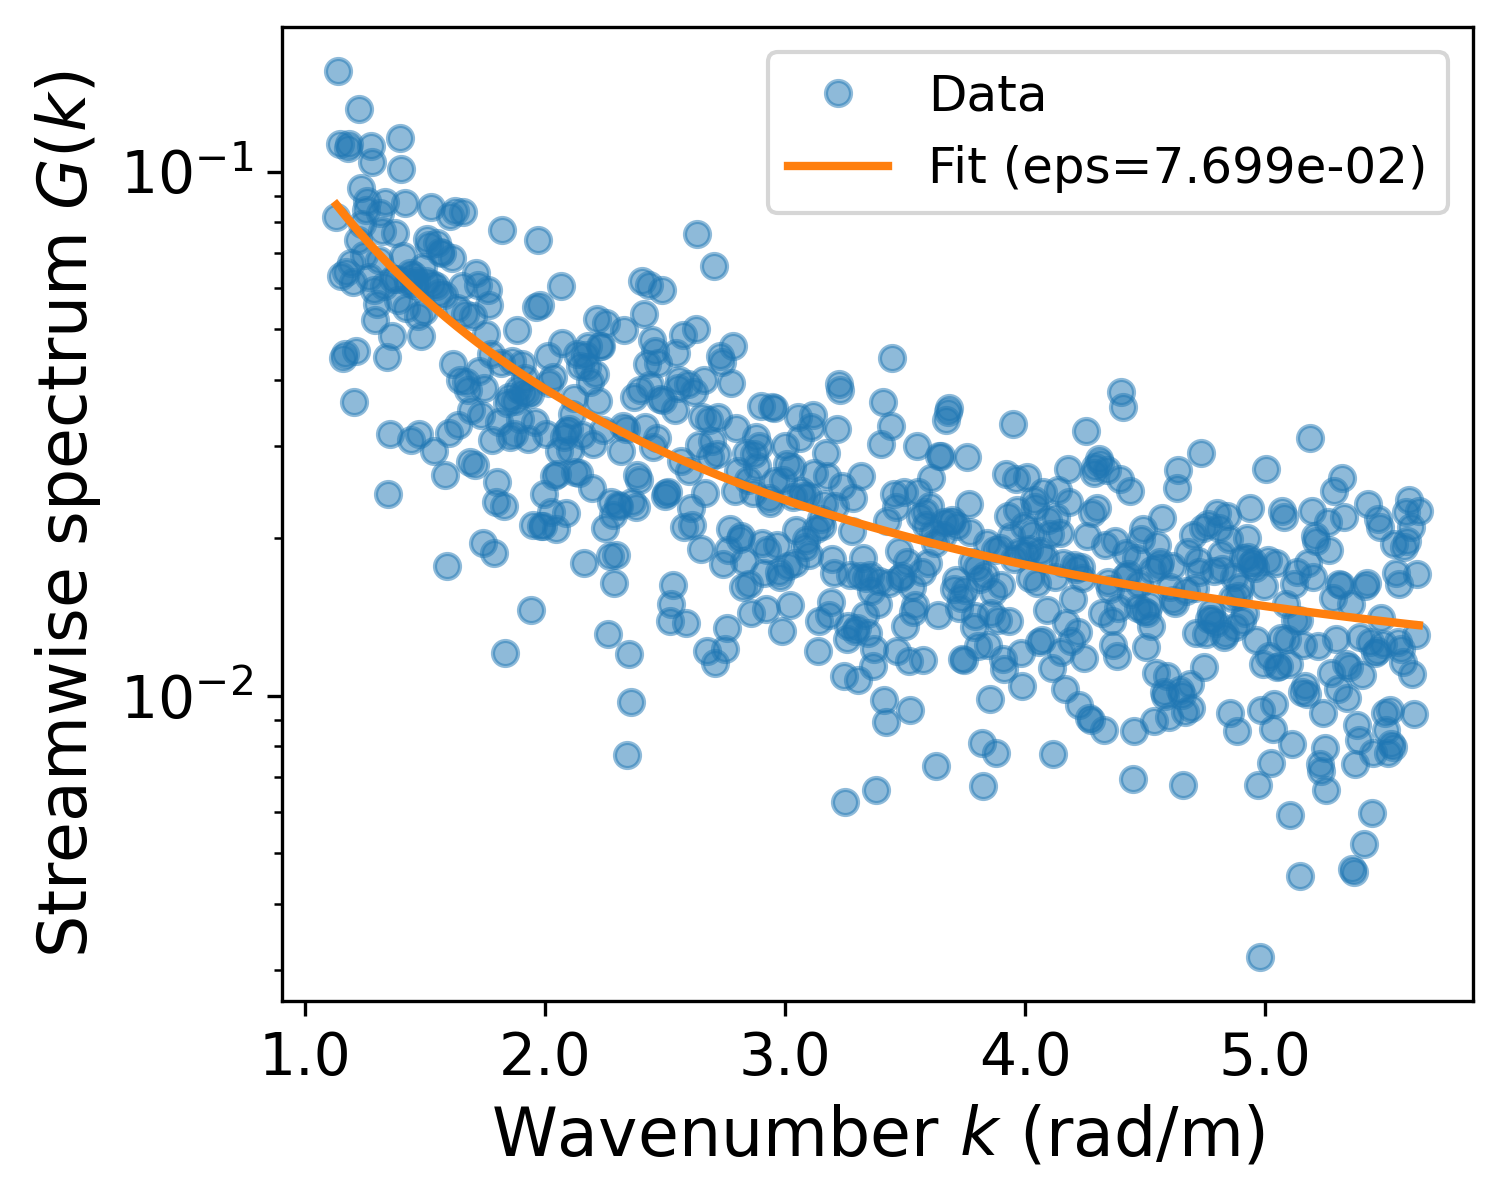

In [5]:
# Display the spectral curve fit for the measurement at height index 0
Image(filename=plot_files[0], width=400, height=300)

In [6]:
# Buoyancy flux from the sonic-temperature / vertical-velocity covariance
B = sonic.buoyancy_flux(burst)
print(f"Buoyancy flux : {B}")

Buoyancy flux : [[0.00132236]]
